**Lifetime Value (LTV) Project**

This notebook focuses on forecasting Customer Lifetime Value (LTV) using historical transaction data. The dataset is transformed into time series sequences to capture temporal patterns and customer behavior over time.

Two forecasting approaches are explored:

*   Long Short-Term Memory (LSTM), a recurrent neural network designed for sequential data,
*   TimeFM, a foundation model for time series forecasting.

Their performance is evaluated to assess their effectiveness in projecting future customer value.

## Setup and Dependencies

### Library

Imports the libraries and dependencies required throughout the project.

Install the TimesFM foundation model library (PyTorch backend).

In [172]:
!pip install -q timesfm[torch]==2.0.0

In [173]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import auth
from google.colab import drive

import timesfm

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

### Auth

Authentication to google account and drive for more google cloud services access

In [174]:
drive.mount('/content/drive')

auth.authenticate_user()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Preparation

### Loader

Query for access data in Google BigQuery

Load data from bigquery

In [176]:
df = pd.read_gbq(sql_query, project_id=project_id, dialect='standard')
df.head()

/tmp/ipykernel_35183/3670017302.py:1: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(sql_query, project_id=project_id, dialect='standard')


,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0
1,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0
2,2025-01-01,MBP,2025-01-03,18,36000.0,DAILYPUSH,188000.0
3,2025-01-01,MBP,2025-01-04,4,8000.0,DAILYPUSH,196000.0
4,2025-01-01,MBP,2025-01-05,7,14000.0,DAILYPUSH,210000.0


In [177]:
df.tail()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
4548,2025-08-10,MBP,2026-01-02,1,2000.0,DAILYPUSH,1280000.0
4549,2025-08-10,MBP,2026-02-01,4,8000.0,DAILYPUSH,1288000.0
4550,2025-08-10,MBP,2026-02-02,6,12000.0,DAILYPUSH,1300000.0
4551,2025-08-10,MBP,2026-02-03,3,6000.0,DAILYPUSH,1306000.0
4552,2025-08-10,MBP,2026-02-10,0,0.0,PURGE,1306000.0


### Exploration

Compact information about data

In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4553 entries, 0 to 4552
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date_created_at        4553 non-null   dbdate 
 1   adnet                  4553 non-null   object 
 2   date_update            4553 non-null   dbdate 
 3   no_of_user             4553 non-null   Int64  
 4   revenue_dailypush      4553 non-null   float64
 5   subject                4553 non-null   object 
 6   revenue_running_total  4553 non-null   float64
dtypes: Int64(1), dbdate(2), float64(2), object(2)
memory usage: 253.6+ KB


Checking unique value

In [179]:
unique_values = df.nunique()
print(unique_values)

date_created_at            30
adnet                       1
date_update               374
no_of_user                 60
revenue_dailypush          55
subject                     3
revenue_running_total    1190
dtype: int64


Checking cohort list

In [180]:
sorted(df['date_created_at'].unique())

[datetime.date(2025, 1, 1),
 datetime.date(2025, 1, 5),
 datetime.date(2025, 1, 12),
 datetime.date(2025, 1, 19),
 datetime.date(2025, 1, 26),
 datetime.date(2025, 2, 2),
 datetime.date(2025, 2, 9),
 datetime.date(2025, 2, 16),
 datetime.date(2025, 2, 23),
 datetime.date(2025, 3, 2),
 datetime.date(2025, 3, 5),
 datetime.date(2025, 3, 8),
 datetime.date(2025, 3, 12),
 datetime.date(2025, 3, 15),
 datetime.date(2025, 3, 17),
 datetime.date(2025, 3, 19),
 datetime.date(2025, 3, 21),
 datetime.date(2025, 3, 22),
 datetime.date(2025, 3, 24),
 datetime.date(2025, 3, 27),
 datetime.date(2025, 3, 29),
 datetime.date(2025, 4, 1),
 datetime.date(2025, 4, 2),
 datetime.date(2025, 4, 5),
 datetime.date(2025, 7, 14),
 datetime.date(2025, 7, 22),
 datetime.date(2025, 7, 28),
 datetime.date(2025, 8, 2),
 datetime.date(2025, 8, 6),
 datetime.date(2025, 8, 10)]

Checking duplicate data

In [181]:
df.duplicated().sum()

np.int64(0)

### Feature Engineering

Adding cohort age (date update - date created) for getting information day every cohort

In [182]:
df['cohort_age'] = (
    df['date_update'] -
    df['date_created_at']
).dt.days

In [183]:
df.head(10)

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age
0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0
1,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0,1
2,2025-01-01,MBP,2025-01-03,18,36000.0,DAILYPUSH,188000.0,2
3,2025-01-01,MBP,2025-01-04,4,8000.0,DAILYPUSH,196000.0,3
4,2025-01-01,MBP,2025-01-05,7,14000.0,DAILYPUSH,210000.0,4
5,2025-01-01,MBP,2025-01-06,7,14000.0,DAILYPUSH,224000.0,5
6,2025-01-01,MBP,2025-01-07,9,18000.0,DAILYPUSH,242000.0,6
7,2025-01-01,MBP,2025-01-08,6,12000.0,DAILYPUSH,254000.0,7
8,2025-01-01,MBP,2025-01-09,7,14000.0,DAILYPUSH,268000.0,8
9,2025-01-01,MBP,2025-01-10,6,12000.0,DAILYPUSH,280000.0,9


Adding day of week using pandas format (Monday is starting from 0)

In [184]:
df['date_created_at'] = pd.to_datetime(df['date_created_at'])
df['date_update'] = pd.to_datetime(df['date_update'])

df['day_of_week'] = df['date_update'].dt.dayofweek

In [185]:
df.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week
0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0,2
1,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0,1,3
2,2025-01-01,MBP,2025-01-03,18,36000.0,DAILYPUSH,188000.0,2,4
3,2025-01-01,MBP,2025-01-04,4,8000.0,DAILYPUSH,196000.0,3,5
4,2025-01-01,MBP,2025-01-05,7,14000.0,DAILYPUSH,210000.0,4,6


Checking data information

In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4553 entries, 0 to 4552
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date_created_at        4553 non-null   datetime64[ns]
 1   adnet                  4553 non-null   object        
 2   date_update            4553 non-null   datetime64[ns]
 3   no_of_user             4553 non-null   Int64         
 4   revenue_dailypush      4553 non-null   float64       
 5   subject                4553 non-null   object        
 6   revenue_running_total  4553 non-null   float64       
 7   cohort_age             4553 non-null   int64         
 8   day_of_week            4553 non-null   int32         
dtypes: Int64(1), datetime64[ns](2), float64(2), int32(1), int64(1), object(2)
memory usage: 306.9+ KB


### Visualization

Distribution of cohort length

In [187]:
cohort_length = (
    df.groupby('date_created_at')['cohort_age']
      .max()
      .add(1)
      .reset_index(name='cohort_length')
)

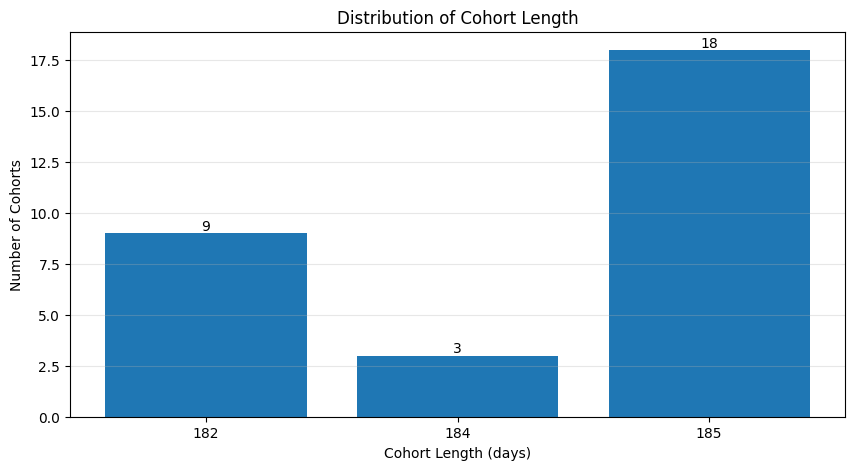

In [188]:
dist = (
    cohort_length['cohort_length']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    dist.index.astype(str),
    dist.values
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.xlabel('Cohort Length (days)')
plt.ylabel('Number of Cohorts')
plt.title('Distribution of Cohort Length')
plt.grid(axis='y', alpha=0.3)

plt.show()

Distribution of running revenue per cohort

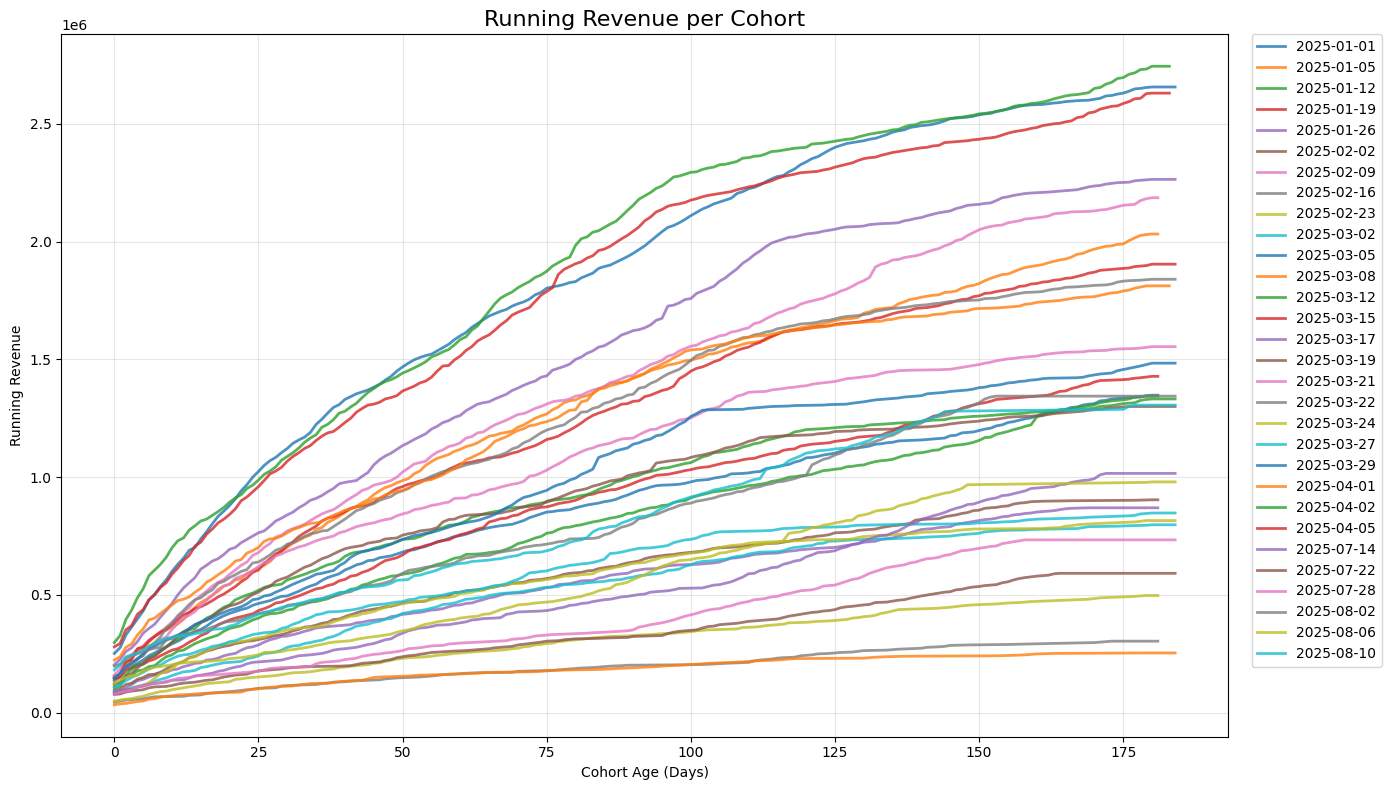

In [189]:
import matplotlib.pyplot as plt
import numpy as np

sample = (
    df['date_created_at']
    .drop_duplicates()
    .sample(30)
)

plt.figure(figsize=(14, 8))

for cohort in sorted(sample):
    temp = (
        df[df['date_created_at'] == cohort]
        .sort_values('cohort_age')
    )

    plt.plot(
        temp['cohort_age'],
        temp['revenue_running_total'],
        linewidth=2,
        alpha=0.8,
        label=cohort.strftime('%Y-%m-%d')
    )

plt.title("Running Revenue per Cohort", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Running Revenue")
plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()

Average revenue daily push distribution per cohort age

<Axes: xlabel='cohort_age'>

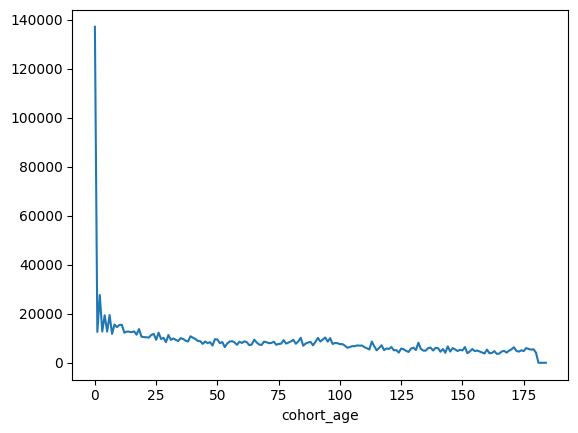

In [190]:
avg_daily = (
    df.groupby('cohort_age')['revenue_dailypush']
    .mean()
)

avg_daily.plot()

Average total revenue distribution per cohort age

<Axes: xlabel='cohort_age'>

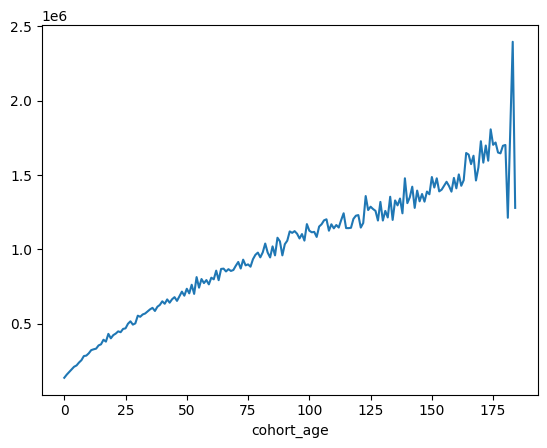

In [191]:
avg_running = (
    df.groupby('cohort_age')['revenue_running_total']
    .mean()
)

avg_running.plot()

Numerical correlation

<Axes: >

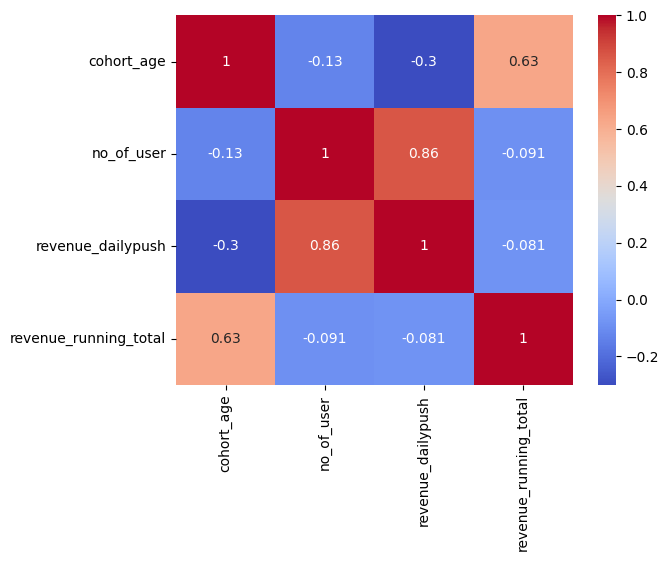

In [192]:
numeric_cols = [
    'cohort_age',
    'no_of_user',
    'revenue_dailypush',
    'revenue_running_total'
]

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

## Preprocessing

### Sort Data

Final preparation with sorting date created and cohort age

In [193]:
df = (
    df
    .sort_values(
        ['date_created_at', 'cohort_age']
    )
    .reset_index(drop=True)
)

In [194]:
df.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week
0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0,2
1,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0,1,3
2,2025-01-01,MBP,2025-01-03,18,36000.0,DAILYPUSH,188000.0,2,4
3,2025-01-01,MBP,2025-01-04,4,8000.0,DAILYPUSH,196000.0,3,5
4,2025-01-01,MBP,2025-01-05,7,14000.0,DAILYPUSH,210000.0,4,6


### Encoding

Create new dataframe for preprocessing process

In [195]:
df_model = df.copy()

subject_encoder = LabelEncoder()
adnet_encoder = LabelEncoder()

Subject encoding

In [196]:
df_model['subject_encoded'] = subject_encoder.fit_transform(df_model['subject'])

In [197]:
df_model.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week,subject_encoded
0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0,2,1
1,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0,1,3,0
2,2025-01-01,MBP,2025-01-03,18,36000.0,DAILYPUSH,188000.0,2,4,0
3,2025-01-01,MBP,2025-01-04,4,8000.0,DAILYPUSH,196000.0,3,5,0
4,2025-01-01,MBP,2025-01-05,7,14000.0,DAILYPUSH,210000.0,4,6,0


Adnet encoding

In [198]:
df_model['adnet_encoded'] = adnet_encoder.fit_transform(df_model['adnet'])

In [199]:
df_model.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week,subject_encoded,adnet_encoded
0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0,2,1,0
1,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0,1,3,0,0
2,2025-01-01,MBP,2025-01-03,18,36000.0,DAILYPUSH,188000.0,2,4,0,0
3,2025-01-01,MBP,2025-01-04,4,8000.0,DAILYPUSH,196000.0,3,5,0,0
4,2025-01-01,MBP,2025-01-05,7,14000.0,DAILYPUSH,210000.0,4,6,0,0


### Feature Selection

Selecting feature for new dataframe

In [200]:
KEEP_COLS = [
    'date_created_at',
    'cohort_age',
    'revenue_running_total',
    'revenue_dailypush',
    'no_of_user',
    'day_of_week',
    'subject_encoded',
    'adnet_encoded'
]

df_model = df_model[KEEP_COLS]

In [201]:
df_model.head()

,date_created_at,cohort_age,revenue_running_total,revenue_dailypush,no_of_user,day_of_week,subject_encoded,adnet_encoded
0,2025-01-01,0,136000.0,136000.0,686,2,1,0
1,2025-01-01,1,152000.0,16000.0,8,3,0,0
2,2025-01-01,2,188000.0,36000.0,18,4,0,0
3,2025-01-01,3,196000.0,8000.0,4,5,0,0
4,2025-01-01,4,210000.0,14000.0,7,6,0,0


### Split Data

Split to train 80% and validation 20% from total cohorts

In [202]:
cohorts = sorted(df_model['date_created_at'].unique())

split_idx = int(len(cohorts) * 0.8)

train_cohorts = cohorts[:split_idx]
val_cohorts = cohorts[split_idx:]

In [203]:
print("Total Train Cohort:", len(train_cohorts))
print("Sample Train Cohort:", train_cohorts)

print("Total Val Cohort:", len(val_cohorts))
print("Sample Val Cohort:", val_cohorts)

Total Train Cohort: 24
Sample Train Cohort: [Timestamp('2025-01-01 00:00:00'), Timestamp('2025-01-05 00:00:00'), Timestamp('2025-01-12 00:00:00'), Timestamp('2025-01-19 00:00:00'), Timestamp('2025-01-26 00:00:00'), Timestamp('2025-02-02 00:00:00'), Timestamp('2025-02-09 00:00:00'), Timestamp('2025-02-16 00:00:00'), Timestamp('2025-02-23 00:00:00'), Timestamp('2025-03-02 00:00:00'), Timestamp('2025-03-05 00:00:00'), Timestamp('2025-03-08 00:00:00'), Timestamp('2025-03-12 00:00:00'), Timestamp('2025-03-15 00:00:00'), Timestamp('2025-03-17 00:00:00'), Timestamp('2025-03-19 00:00:00'), Timestamp('2025-03-21 00:00:00'), Timestamp('2025-03-22 00:00:00'), Timestamp('2025-03-24 00:00:00'), Timestamp('2025-03-27 00:00:00'), Timestamp('2025-03-29 00:00:00'), Timestamp('2025-04-01 00:00:00'), Timestamp('2025-04-02 00:00:00'), Timestamp('2025-04-05 00:00:00')]
Total Val Cohort: 6
Sample Val Cohort: [Timestamp('2025-07-14 00:00:00'), Timestamp('2025-07-22 00:00:00'), Timestamp('2025-07-28 00:00:00'

Insert to pandas for next step (forecasting)

In [204]:
train_df = df_model[df_model['date_created_at'].isin(train_cohorts)]
val_df = df_model[df_model['date_created_at'].isin(val_cohorts)]

In [205]:
train_df.head()

,date_created_at,cohort_age,revenue_running_total,revenue_dailypush,no_of_user,day_of_week,subject_encoded,adnet_encoded
0,2025-01-01,0,136000.0,136000.0,686,2,1,0
1,2025-01-01,1,152000.0,16000.0,8,3,0,0
2,2025-01-01,2,188000.0,36000.0,18,4,0,0
3,2025-01-01,3,196000.0,8000.0,4,5,0,0
4,2025-01-01,4,210000.0,14000.0,7,6,0,0


### Target

Setup feature and target for training

In [206]:
FEATURES = [
    'revenue_running_total',
    'cohort_age',
    'day_of_week',
]

TARGET = 'revenue_running_total'

TimesFM is a univariate foundation model that performs its own input normalization internally. Manual Min-Max scaling is therefore not applied here — the model consumes and forecasts `revenue_running_total` directly in its original scale, using only the target series (the other features are kept for reference).

Checking data train

In [207]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3707 entries, 0 to 3706
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date_created_at        3707 non-null   datetime64[ns]
 1   cohort_age             3707 non-null   int64         
 2   revenue_running_total  3707 non-null   float64       
 3   revenue_dailypush      3707 non-null   float64       
 4   no_of_user             3707 non-null   Int64         
 5   day_of_week            3707 non-null   int32         
 6   subject_encoded        3707 non-null   int64         
 7   adnet_encoded          3707 non-null   int64         
dtypes: Int64(1), datetime64[ns](1), float64(2), int32(1), int64(3)
memory usage: 249.8 KB


In [208]:
train_df.head()

,date_created_at,cohort_age,revenue_running_total,revenue_dailypush,no_of_user,day_of_week,subject_encoded,adnet_encoded
0,2025-01-01,0,136000.0,136000.0,686,2,1,0
1,2025-01-01,1,152000.0,16000.0,8,3,0,0
2,2025-01-01,2,188000.0,36000.0,18,4,0,0
3,2025-01-01,3,196000.0,8000.0,4,5,0,0
4,2025-01-01,4,210000.0,14000.0,7,6,0,0


Checking data validation

In [209]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 846 entries, 3707 to 4552
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date_created_at        846 non-null    datetime64[ns]
 1   cohort_age             846 non-null    int64         
 2   revenue_running_total  846 non-null    float64       
 3   revenue_dailypush      846 non-null    float64       
 4   no_of_user             846 non-null    Int64         
 5   day_of_week            846 non-null    int32         
 6   subject_encoded        846 non-null    int64         
 7   adnet_encoded          846 non-null    int64         
dtypes: Int64(1), datetime64[ns](1), float64(2), int32(1), int64(3)
memory usage: 57.0 KB


In [210]:
val_df.head()

,date_created_at,cohort_age,revenue_running_total,revenue_dailypush,no_of_user,day_of_week,subject_encoded,adnet_encoded
3707,2025-07-14,0,88000.0,88000.0,1244,0,1,0
3708,2025-07-14,2,98000.0,10000.0,5,2,0,0
3709,2025-07-14,3,100000.0,2000.0,1,3,0,0
3710,2025-07-14,4,108000.0,8000.0,4,4,0,0
3711,2025-07-14,5,114000.0,6000.0,3,5,0,0


## Forecast Setup

### Series Builder

TimesFM forecasts a whole horizon from a contiguous context window, so instead of sliding windows we simply extract the ordered target series for each cohort. TimesFM 2.5 no longer requires a frequency indicator — the model handles the temporal pattern automatically.

In [211]:
CONTEXT_LEN = 2048   # max context length (2.5 supports up to 16k)
HORIZON_LEN = 512    # max forecast horizon per call
CONTEXT_MIN = 30     # minimum history required before forecasting
# Note: TimesFM 2.5 removed the frequency indicator — no FREQ needed

def get_series(data, cohort):
    """Return the ordered univariate target series for one cohort."""
    s = (
        data[data['date_created_at'] == cohort]
        .sort_values('cohort_age')
    )
    return s[TARGET].values.astype(float)

## Modeling

### TimesFM

TimesFM is a pretrained foundation model, so it is used zero-shot — there is no training loop. Load the 2.0 500M PyTorch checkpoint with the fixed architecture parameters.

In [212]:
import torch
import timesfm

torch.set_float32_matmul_precision("high")

# TimesFM 2.5 – 200M parameter checkpoint (PyTorch)
tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

tfm.compile(
    timesfm.ForecastConfig(
        max_context=CONTEXT_LEN,
        max_horizon=HORIZON_LEN,
        normalize_inputs=True,
        use_continuous_quantile_head=False,   # point forecast only
        force_flip_invariance=False,
        infer_is_positive=True,               # revenue is always >= 0
        fix_quantile_crossing=True,
    )
)

## Evaluation

### Visualization

Evaluate zero-shot on the validation cohorts: for each cohort use all but the last `EVAL_HORIZON` days as context and forecast the held-out tail, then compare against the actuals.

In [213]:
EVAL_HORIZON = 30

eval_contexts = []
eval_actuals  = []

for c in val_cohorts:
    s = get_series(val_df, c)
    if len(s) < CONTEXT_MIN + EVAL_HORIZON:
        continue
    eval_contexts.append(s[:-EVAL_HORIZON])
    eval_actuals.append(s[-EVAL_HORIZON:])

print("Evaluated cohorts:", len(eval_contexts))

# TimesFM 2.5 forecast: pass horizon and list of context arrays
point_forecast, _ = tfm.forecast(
    horizon=EVAL_HORIZON,
    inputs=eval_contexts,
)

y_pred = np.concatenate([point_forecast[i, :EVAL_HORIZON] for i in range(len(eval_contexts))])
y_val  = np.concatenate(eval_actuals)

Evaluated cohorts: 6


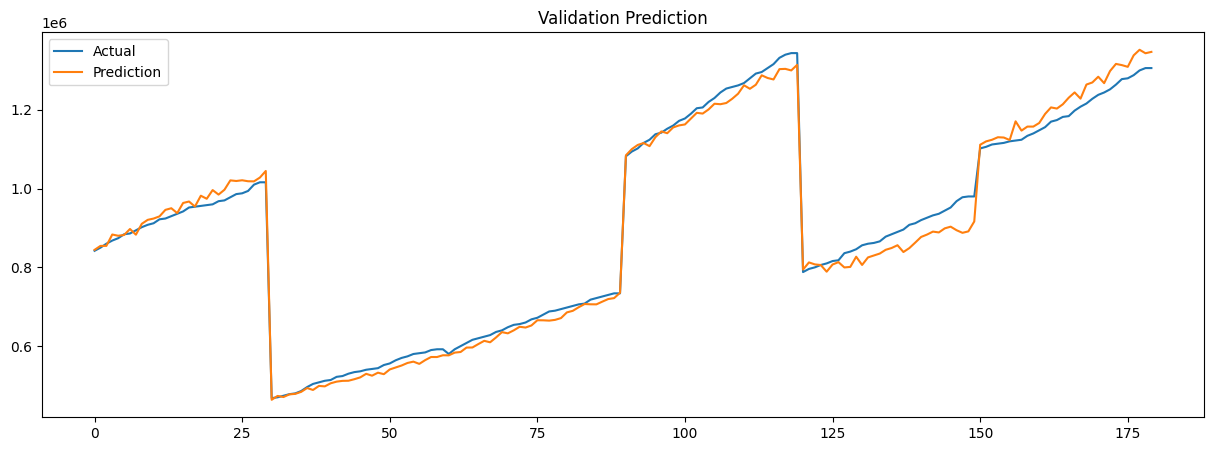

In [214]:
plt.figure(figsize=(15,5))

plt.plot(
    y_val[:200],
    label='Actual'
)

plt.plot(
    y_pred[:200],
    label='Prediction'
)

plt.title('Validation Prediction')

plt.legend()

plt.show()

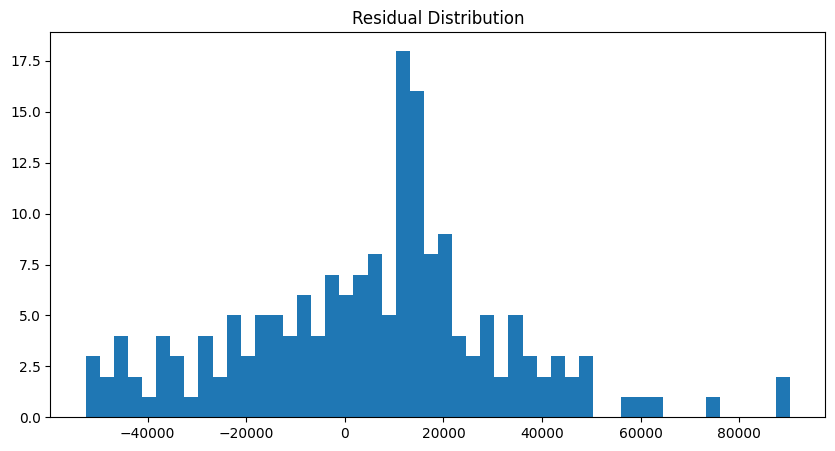

In [215]:
residuals = y_val - y_pred

plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=50
)

plt.title('Residual Distribution')

plt.show()

### Metrics

Detail evaluation metrics in MAE, RMSE, MAPE

In [216]:
mae = mean_absolute_error(
    y_val,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred
    )
)

mape = mean_absolute_percentage_error(
    y_val,
    y_pred
) * 100

In [217]:
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 21692.416319
RMSE : 27302.294671
MAPE : 2.37%


## Projection

Use the first `SEED_DAYS` of a cohort as context and let TimesFM forecast all remaining days in a single multi-horizon call (no recursive stepping needed).

Select cohort and run projection

In [218]:


candidates = [
    c for c in val_cohorts
    if int(df[df['date_created_at'] == c]['cohort_age'].max()) >= SEED_DAYS
]

print("Eligible cohorts:", len(candidates))

cohort = candidates[0]

cohort_raw = (
    df[df['date_created_at'] == cohort]
    .sort_values('cohort_age')
    .reset_index(drop=True)
)

seed_mask     = cohort_raw['cohort_age'] < SEED_DAYS
context       = cohort_raw.loc[seed_mask, TARGET].values.astype(float)
actual_future = cohort_raw.loc[~seed_mask, TARGET].values.astype(float)
n_steps       = len(actual_future)

print("Cohort      :", cohort)
print("Seed days   :", len(context))
print("Future days :", n_steps)

# Forecast all remaining days in one call
point_forecast, _ = tfm.forecast(
    horizon=n_steps,
    inputs=[context],
)
pred_future = point_forecast[0, :n_steps]

print(f"Predicted running total at day {SEED_DAYS + n_steps - 1}: {pred_future[-1]:,.0f}")
print(f"Actual    running total at day {SEED_DAYS + n_steps - 1}: {actual_future[-1]:,.0f}")

Eligible cohorts: 6
Cohort      : 2025-07-14 00:00:00
Seed days   : 78
Future days : 78
Predicted running total at day 167: 936,568
Actual    running total at day 167: 1,016,000


Evaluation at day+30, day+60, and full horizon

In [219]:
milestones = {'day+30': 30, 'day+60': 60, 'full': n_steps}

for label, days in milestones.items():
    n = min(days, len(actual_future), len(pred_future))
    if n == 0:
        print(f"{label}: not enough data")
        continue
    mae  = mean_absolute_error(actual_future[:n], pred_future[:n])
    rmse = np.sqrt(mean_squared_error(actual_future[:n], pred_future[:n]))
    mape = mean_absolute_percentage_error(actual_future[:n], pred_future[:n]) * 100
    print(f"[{label:>7}] MAE={mae:>12,.0f}  RMSE={rmse:>12,.0f}  MAPE={mape:.2f}%")

[ day+30] MAE=      11,540  RMSE=      15,075  MAPE=1.89%
[ day+60] MAE=      39,079  RMSE=      50,995  MAPE=4.97%
[   full] MAE=      49,902  RMSE=      61,042  MAPE=5.88%


Actual vs projection visualization

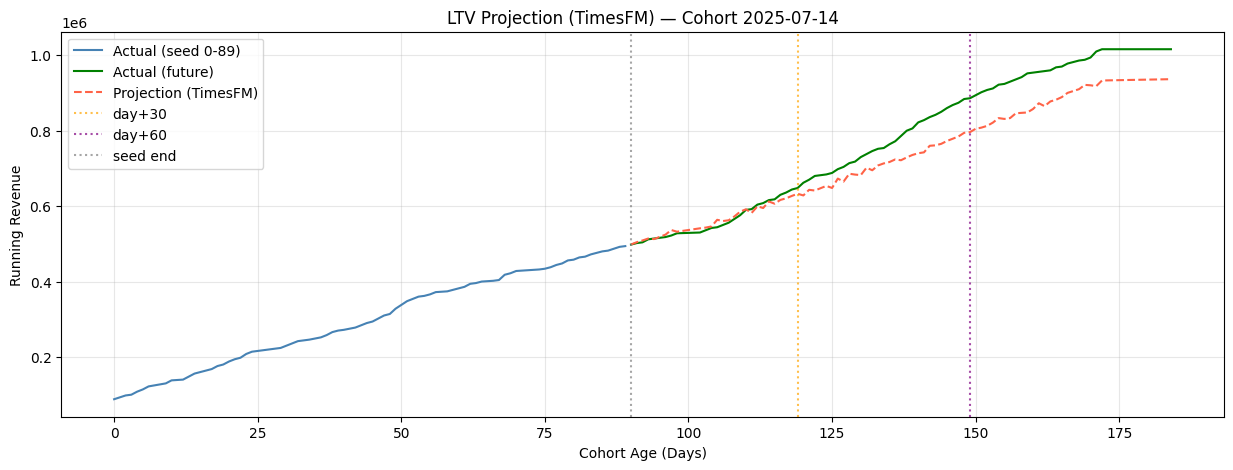

In [220]:
seed_age   = cohort_raw.loc[seed_mask, 'cohort_age'].values
future_age = cohort_raw.loc[~seed_mask, 'cohort_age'].values[:n_steps]
pred_age   = future_age[:len(pred_future)]

plt.figure(figsize=(15, 5))

plt.plot(seed_age,   context,       label='Actual (seed 0-89)',   color='steelblue')
plt.plot(future_age, actual_future, label='Actual (future)',       color='green')
plt.plot(pred_age,   pred_future,   label='Projection (TimesFM)',  color='tomato', linestyle='--')

for offset, color in [(30, 'orange'), (60, 'purple')]:
    day = SEED_DAYS + offset - 1
    if len(future_age) > 0 and day <= future_age[-1]:
        plt.axvline(x=day, color=color, linestyle=':', alpha=0.7, label=f'day+{offset}')

plt.axvline(x=SEED_DAYS, color='gray', linestyle=':', alpha=0.7, label='seed end')
plt.title(f'LTV Projection (TimesFM) \u2014 Cohort {str(cohort)[:10]}')
plt.xlabel('Cohort Age (Days)')
plt.ylabel('Running Revenue')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Testing on Unseen Data

This section evaluates TimesFM on a completely hold-out dataset (`linkit-rnd-475909.country_summary.ml_lstm_unseen_5cohorts`) containing 5 unseen cohorts that the model has never been exposed to.

Because TimesFM is a **univariate, zero-shot** foundation model, the unseen data needs only minimal preparation: load the raw table, derive `cohort_age` (used to order the series and slice seed/horizon), and sort. No scaler or encoder is fit, no scaling is applied, and `day_of_week` / encodings are not needed — the model consumes the raw `revenue_running_total` series directly.

### Loader

Query the unseen testing table from Google BigQuery

In [221]:
df_unseen = pd.read_gbq(unseen_query, project_id=project_id, dialect='standard')
df_unseen.head()

/tmp/ipykernel_35183/1259746139.py:1: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_unseen = pd.read_gbq(unseen_query, project_id=project_id, dialect='standard')


,date_created_at,camp_sub_keyword,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
0,2025-04-06,NON,MBP,2025-04-06,1569,240000.0,FIRSTPUSH,240000.0
1,2025-04-06,NON,MBP,2025-04-07,11,22000.0,DAILYPUSH,262000.0
2,2025-04-06,NON,MBP,2025-04-08,31,62000.0,DAILYPUSH,324000.0
3,2025-04-06,NON,MBP,2025-04-09,9,18000.0,DAILYPUSH,342000.0
4,2025-04-06,NON,MBP,2025-04-10,21,42000.0,DAILYPUSH,384000.0


### Feature Engineering

Derive `cohort_age` and sort the same way as the training data. Scaling, encoding, and `day_of_week` are intentionally skipped since TimesFM only uses the ordered target series.

In [222]:
df_unseen['date_created_at'] = pd.to_datetime(df_unseen['date_created_at'])
df_unseen['date_update']     = pd.to_datetime(df_unseen['date_update'])

df_unseen['cohort_age'] = (
    df_unseen['date_update'] - df_unseen['date_created_at']
).dt.days

df_unseen = (
    df_unseen
    .sort_values(['date_created_at', 'cohort_age'])
    .reset_index(drop=True)
)

df_unseen.head()

,date_created_at,camp_sub_keyword,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age
0,2025-04-06,NON,MBP,2025-04-06,1569,240000.0,FIRSTPUSH,240000.0,0
1,2025-04-06,NON,MBP,2025-04-07,11,22000.0,DAILYPUSH,262000.0,1
2,2025-04-06,NON,MBP,2025-04-08,31,62000.0,DAILYPUSH,324000.0,2
3,2025-04-06,NON,MBP,2025-04-09,9,18000.0,DAILYPUSH,342000.0,3
4,2025-04-06,NON,MBP,2025-04-10,21,42000.0,DAILYPUSH,384000.0,4


Checking unseen cohorts and their length

In [223]:
unseen_cohorts = sorted(df_unseen['date_created_at'].unique())

print("Total unseen cohorts:", len(unseen_cohorts))
for c in unseen_cohorts:
    days = int(df_unseen[df_unseen['date_created_at'] == c]['cohort_age'].max()) + 1
    print(f"  {str(c)[:10]} -> {days} days")

Total unseen cohorts: 5
  2025-04-06 -> 184 days
  2025-08-04 -> 185 days
  2025-08-21 -> 185 days
  2025-09-22 -> 182 days
  2025-10-31 -> 182 days


### Visualization

Distribution of running revenue per cohort

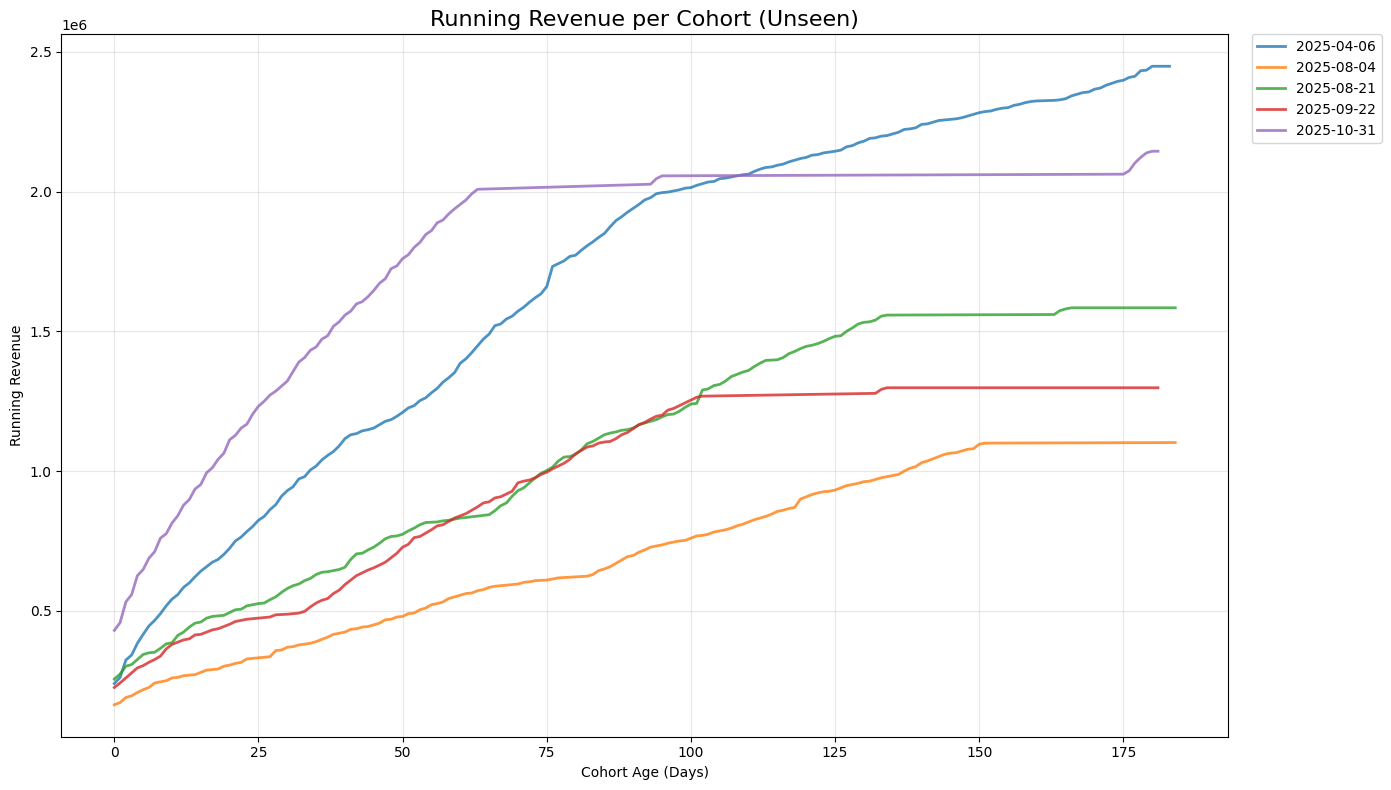

In [224]:
plt.figure(figsize=(14, 8))

for cohort in unseen_cohorts:
    temp = (
        df_unseen[df_unseen['date_created_at'] == cohort]
        .sort_values('cohort_age')
    )

    plt.plot(
        temp['cohort_age'],
        temp['revenue_running_total'],
        linewidth=2,
        alpha=0.8,
        label=pd.Timestamp(cohort).strftime('%Y-%m-%d')
    )

plt.title("Running Revenue per Cohort (Unseen)", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Running Revenue")
plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()

### Forecast

For each unseen cohort, use the first `SEED_DAYS` days as context and let TimesFM forecast the remaining horizon in a single call. If a cohort is shorter than `SEED_DAYS`, the seed length is reduced so at least one day is forecast.

In [225]:
def project_cohort(cohort_raw, seed_len):
    """
    Project LTV for a cohort using TimesFM.
    
    Args:
        cohort_raw: DataFrame for one cohort, sorted by cohort_age
        seed_len: Number of days to use as context/seed
    
    Returns:
        (context, actual_future, pred_future, n_steps)
    """
    seed_mask     = cohort_raw['cohort_age'] < seed_len
    context       = cohort_raw.loc[seed_mask, TARGET].values.astype(float)
    actual_future = cohort_raw.loc[~seed_mask, TARGET].values.astype(float)
    n_steps       = len(actual_future)
    
    # Forecast all remaining days in one call
    point_forecast, _ = tfm.forecast(
        horizon=n_steps,
        inputs=[context],
    )
    pred_future = point_forecast[0, :n_steps]
    
    return context, actual_future, pred_future, n_steps

In [226]:
results = {}

for cohort in unseen_cohorts:
    cohort_raw = (
        df_unseen[df_unseen['date_created_at'] == cohort]
        .sort_values('cohort_age')
        .reset_index(drop=True)
    )

    seed_len = min(SEED_DAYS, len(cohort_raw) - 1)
    context, actual_future, pred_future, n_steps = project_cohort(cohort_raw, seed_len)

    results[cohort] = {
        'cohort_raw': cohort_raw,
        'seed_len': seed_len,
        'context': context,
        'actual_future': actual_future,
        'pred_future': pred_future,
        'n_steps': n_steps,
    }

    # Calculate MAPE for full horizon
    mape_full = mean_absolute_percentage_error(actual_future, pred_future) * 100
    print(f"{str(cohort)[:10]}: seed={seed_len}d, forecast={n_steps}d  | final pred={pred_future[-1]:,.0f}  actual={actual_future[-1]:,.0f}  MAPE={mape_full:.2f}%")

2025-04-06: seed=90d, forecast=87d  | final pred=3,397,290  actual=2,448,000  MAPE=22.77%
2025-08-04: seed=90d, forecast=62d  | final pred=1,140,101  actual=1,102,000  MAPE=3.07%
2025-08-21: seed=90d, forecast=49d  | final pred=1,521,425  actual=1,584,000  MAPE=3.97%
2025-09-22: seed=90d, forecast=17d  | final pred=1,299,683  actual=1,298,000  MAPE=1.36%
2025-10-31: seed=73d, forecast=10d  | final pred=2,153,607  actual=2,144,000  MAPE=0.46%


Actual vs projection visualization for each unseen cohort

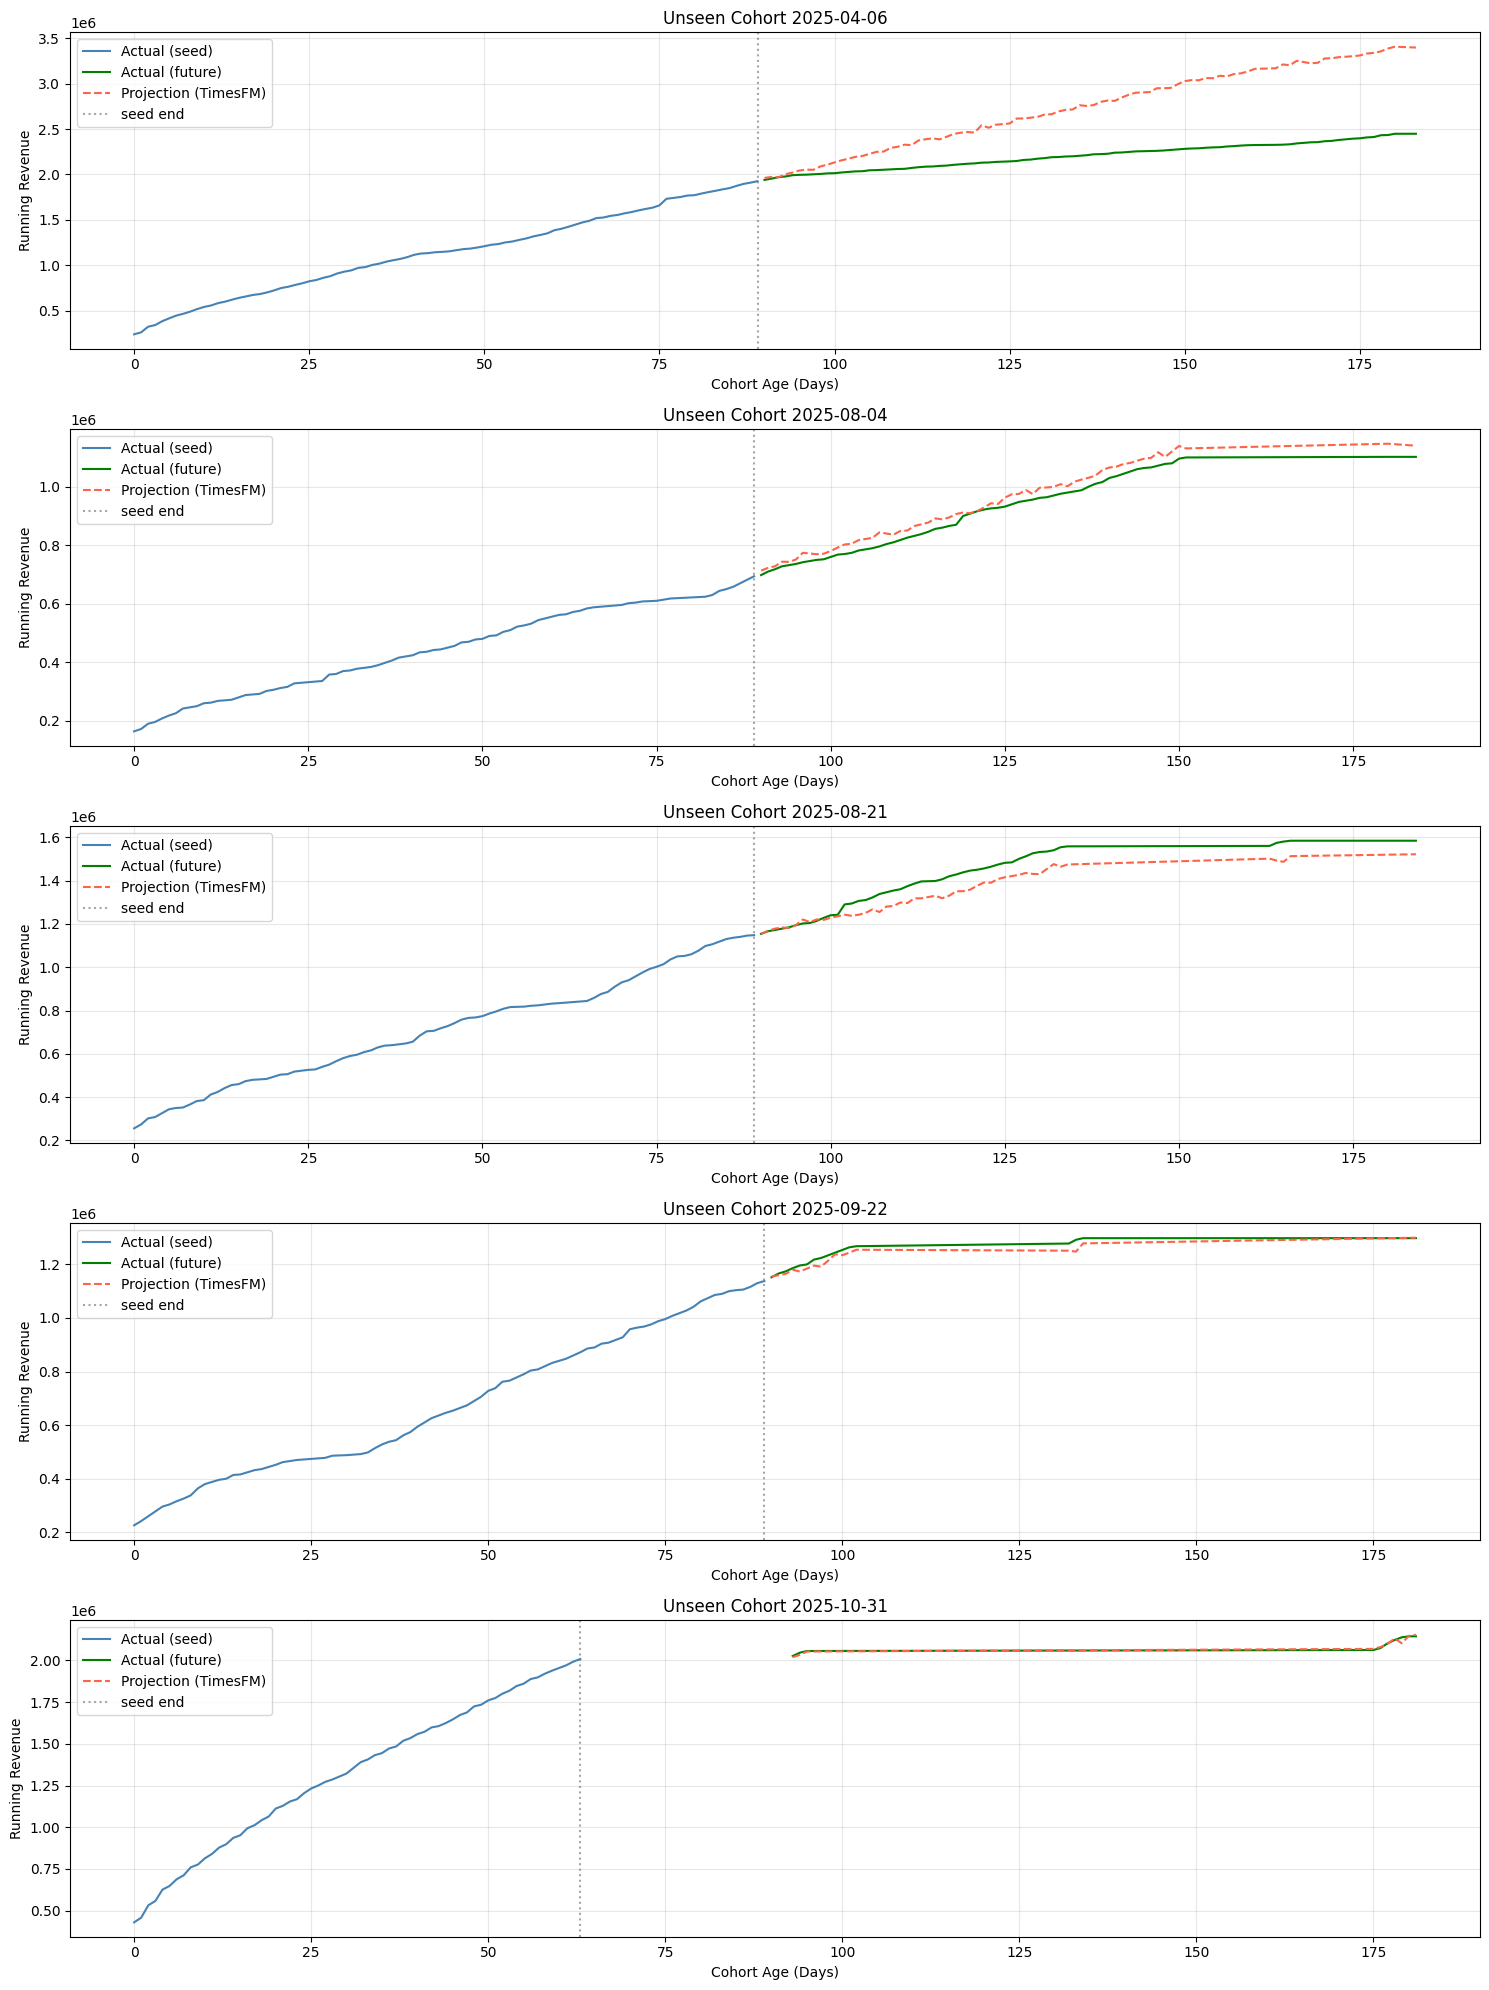

In [227]:
n_cohorts = len(results)
fig, axes = plt.subplots(n_cohorts, 1, figsize=(15, 4 * n_cohorts))

if n_cohorts == 1:
    axes = [axes]

for ax, (cohort, r) in zip(axes, results.items()):
    cohort_raw = r['cohort_raw']
    seed_len   = r['seed_len']
    n_steps    = r['n_steps']

    # Reconstruct the seed mask to properly align ages with context/actual_future
    seed_mask  = cohort_raw['cohort_age'] < seed_len
    ages       = cohort_raw['cohort_age'].values
    seed_age   = ages[seed_mask]
    future_age = ages[~seed_mask][:n_steps]
    pred_age   = future_age[:len(r['pred_future'])]

    ax.plot(seed_age,   r['context'],       label='Actual (seed)',        color='steelblue')
    ax.plot(future_age, r['actual_future'], label='Actual (future)',      color='green')
    ax.plot(pred_age,   r['pred_future'],   label='Projection (TimesFM)', color='tomato', linestyle='--')

    if len(seed_age) > 0:
        ax.axvline(x=seed_age[-1], color='gray', linestyle=':', alpha=0.7, label='seed end')

    ax.set_title(f'Unseen Cohort {str(cohort)[:10]}')
    ax.set_xlabel('Cohort Age (Days)')
    ax.set_ylabel('Running Revenue')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()